In [ ]:
import os
import json
import re
import time
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import anthropic
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)

ANTHROPIC_API_KEY = os.environ.get("ANTHROPIC_API_KEY", "sk-ant")
MODEL = "claude-haiku-4-5-20251001"

client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)

DATA = Path("../data")
df = pd.read_csv(DATA / "twitter_sentiment_data.csv")

df = df[df["sentiment"].isin([-1, 1])].reset_index(drop=True)

LABEL_MAP = {-1: "anti", 1: "pro"}
LABEL_TO_INT = {v: k for k, v in LABEL_MAP.items()}

example_rows = df.groupby("sentiment").sample(n=2, random_state=99)
example_ids = set(example_rows["tweetid"].tolist())

examples_5 = [(r["message"], LABEL_MAP[r["sentiment"]]) for _, r in example_rows.iterrows()]

sample_df = (
    df[~df["tweetid"].isin(example_ids)]
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)
print(f"Rows to classify: {len(sample_df)}  |  Few-shot examples: {len(examples_5)}")

SYSTEM_PROMPT = (
    "You classify tweets about climate change into exactly one of two categories:\n"
    "- 'pro': supports the belief that human-caused climate change is real (a believer)\n"
    "- 'anti': rejects or denies the belief in human-caused climate change (a denier)\n\n"
    "Respond ONLY in valid JSON: "
    '{"label": "pro" | "anti", '
    '"explanation": "2-3 sentences justifying your decision."}'
)

Rows to classify: 26948  |  Few-shot examples: 4


In [ ]:
from anthropic.types.messages.batch_create_params import Request

CACHE_DIR = Path("llm_cache")
CACHE_DIR.mkdir(exist_ok=True)

strategy_name = "batch_examples_2class"
cache_file = CACHE_DIR / f"{strategy_name}.json"
batch_id_file = CACHE_DIR / f"{strategy_name}_batch_id.txt"

cache = json.loads(cache_file.read_text()) if cache_file.exists() else {}

def build_user_msg(tweet_text, examples):
    msg = ""
    for ex_text, ex_label in examples:
        msg += f'Tweet: "{ex_text[:300]}"\n'
        msg += f'Output: {{"label": "{ex_label}", "explanation": "..."}}\n\n'
    msg += f'Tweet: "{tweet_text[:500]}"\nOutput:'
    return msg

requests = []
for _, row in sample_df.iterrows():
    review_id = str(row["tweetid"])
    if review_id in cache:
        continue
    requests.append(Request(
        custom_id=review_id,
        params={
            "model": MODEL,
            "max_tokens": 256,
            "temperature": 0.0,
            "system": SYSTEM_PROMPT,
            "messages": [
                {"role": "user", "content": build_user_msg(row["message"], examples_5)}
            ],
        },
    ))

print(f"Already cached: {len(cache)}")
print(f"New requests to submit: {len(requests)}")

if requests:
    batch = client.messages.batches.create(requests=requests)
    batch_id_file.write_text(batch.id)
    print(f"Submitted batch: {batch.id}")
    print(f"Initial status: {batch.processing_status}")
else:
    print("Nothing to submit — cache already covers all rows.")

Already cached: 0
New requests to submit: 26948
Submitted batch: msgbatch_01R1kd7R8M77PnKLQn1hCpxk
Initial status: in_progress


In [ ]:
batch_id = batch_id_file.read_text().strip()
print(f"Polling batch {batch_id}...")

while True:
    batch = client.messages.batches.retrieve(batch_id)
    c = batch.request_counts
    print(
        f"status={batch.processing_status}  "
        f"processing={c.processing}  succeeded={c.succeeded}  "
        f"errored={c.errored}  canceled={c.canceled}  expired={c.expired}"
    )
    if batch.processing_status == "ended":
        break
    time.sleep(60)

print("Batch ended.")

Polling batch msgbatch_01R1kd7R8M77PnKLQn1hCpxk...
status=ended  processing=0  succeeded=26948  errored=0  canceled=0  expired=0
Batch ended.


In [ ]:
batch_id = batch_id_file.read_text().strip()

succeeded = errored = 0
for result in client.messages.batches.results(batch_id):
    custom_id = result.custom_id
    if result.result.type == "succeeded":
        cache[custom_id] = result.result.message.content[0].text
        succeeded += 1
    else:
        errored += 1
        if errored <= 5:
            print(f"  error {custom_id}: {result.result}")

cache_file.write_text(json.dumps(cache, indent=2))
print(f"Succeeded: {succeeded}  |  Errored: {errored}  |  Total cached: {len(cache)}")

Succeeded: 26948  |  Errored: 0  |  Total cached: 26948


Parsed 26947 predictions  |  parse failures: 1
Accuracy:  0.9595
Precision: 0.8988 (macro)
Recall:    0.9590 (macro)
F1-Score:  0.9255 (macro)


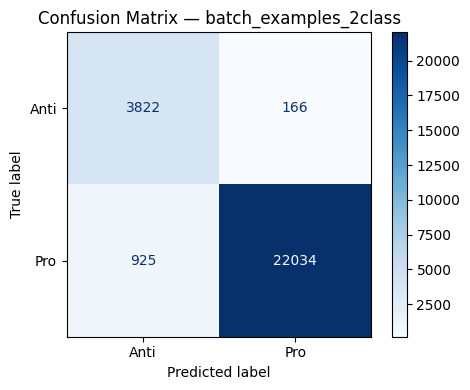

In [17]:
def parse_llm_response(raw_response):
    try:
        result = json.loads(raw_response)
        return result.get("label", "").strip().lower(), result.get("explanation", "")
    except json.JSONDecodeError:
        pass

    json_match = re.search(r'\{.*\}', raw_response, re.DOTALL)
    if json_match:
        try:
            result = json.loads(json_match.group())
            return result.get("label", "").strip().lower(), result.get("explanation", "")
        except json.JSONDecodeError:
            pass

    label_match = re.search(r'"label"\s*:\s*"(pro|anti)"', raw_response, re.IGNORECASE)
    label = label_match.group(1).lower() if label_match else "unknown"
    expl_match = re.search(r'"explanation"\s*:\s*"(.*?)"', raw_response, re.DOTALL)
    explanation = expl_match.group(1) if expl_match else raw_response
    return label, explanation


cache = json.loads(cache_file.read_text())

predicted_labels = []
ground_truth = []
explanations = []
parse_failures = 0

for _, row in sample_df.iterrows():
    review_id = str(row["tweetid"])
    if review_id not in cache:
        continue
    label_str, explanation = parse_llm_response(cache[review_id])
    pred_int = LABEL_TO_INT.get(label_str)
    if pred_int is None:
        parse_failures += 1
        continue
    predicted_labels.append(pred_int)
    ground_truth.append(row["sentiment"])
    explanations.append(explanation)

print(f"Parsed {len(predicted_labels)} predictions  |  parse failures: {parse_failures}")

acc = accuracy_score(ground_truth, predicted_labels)
prec = precision_score(ground_truth, predicted_labels, average="macro", zero_division=0)
rec = recall_score(ground_truth, predicted_labels, average="macro", zero_division=0)
f1 = f1_score(ground_truth, predicted_labels, average="macro", zero_division=0)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f} (macro)")
print(f"Recall:    {rec:.4f} (macro)")
print(f"F1-Score:  {f1:.4f} (macro)")

cm = confusion_matrix(ground_truth, predicted_labels, labels=[-1, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Anti", "Pro"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title(f"Confusion Matrix — {strategy_name}")
plt.tight_layout()
plt.savefig(f"confusion_matrix_{strategy_name}.png", dpi=150)
plt.show()